# HRN output analysis

Every notebook in `notebooks/model_analysis/` renders the same eleven sections, in
the same order, from the same code in `notebooks/utils/hcast_analysis_utils.py`, so
a section of one family's notebook can be read directly against the same section of
another's. Shared objective names come from `FAMILY_PROFILES`, while each notebook
defines its own editable `BASELINE_BY_DATASET` and `MANUAL_RUNS` lists.

Where a section comes out shorter for one family, that is a fact about the family
rather than a difference in what was asked for: the code drops a loss term the runs
never logged, a diagnostic panel that no selected run moved off zero, and a
gradient-support block the architecture does not contain. Each of those prints a
line saying which and why.

## Setup

In [1]:
from pathlib import Path
import sys

import numpy as np

cwd = Path.cwd().resolve()
repo_root = next((p for p in [cwd, *cwd.parents] if (p / 'configs').is_dir()), cwd)
notebook_utils_dir = repo_root / 'notebooks' / 'utils'
if str(notebook_utils_dir) not in sys.path:
    sys.path.insert(0, str(notebook_utils_dir))

import thesis_style
import hcast_analysis_utils as hu
from hcast_analysis_utils import HCastAnalysis, resolve_project_root, show_markdown

# The one line that differs between the five model-analysis notebooks.
FAMILY = 'hrn'

# Which decoders every figure and table below shows: 'both', 'independent' or
# 'topdown'. The two decoders do not select the same epoch, so 'both' is the
# default; the other two read the whole page for one decoder and halve the
# curves in every panel. Individual calls can still override it with
# `decoder_view=`.
DECODER_VIEW = hu.set_decoder_view('independent')

PROJECT_ROOT = resolve_project_root()
OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')

# Figures are runtime artifacts, so they live under /scratch, not in the repo.
# Copy the PDFs into images/hrn/ of the thesis tree when including them.
FIGURE_DIR = hu.set_figure_dir(OUTPUTS_ROOT / 'analysis' / 'model_analysis' / FAMILY / 'figures')

print(f'Project root: {PROJECT_ROOT}')
print(f'Family:       {hu.FAMILY_PROFILES[FAMILY].display_name}')
print(f'Decoders:     {hu.decoder_view_phrase()} decoding')
print(f'Figures:      {FIGURE_DIR}')

Project root: /home/g.saggini1/lexicographic_deep_learning_detailed_study
Family:       HRN
Decoders:     independent decoding
Figures:      /scratch/g.saggini1/outputs/analysis/model_analysis/hrn/figures


## Run matrix

Choose the runs shown by editing `BASELINE_BY_DATASET` and `MANUAL_RUNS` below.
Every directory and label is local and explicit, so entries can be freely added,
removed, renamed or restricted to individual datasets.

A configured arm with no readable seed directory - not launched yet, or renamed
since the profile was written - is named explicitly rather than dropped silently,
so "this family has no such arm" stays distinguishable from "its arm is not on
disk". The gradient-block report that follows states which blocks the logs actually
carry and flags any run whose config selects a block its logs do not have.

In [2]:
INCLUDE_BASELINES = True
BASELINE_BY_DATASET = {
    'cifar-100': {'run_dir': 'hrn_cifar100_level_conditional', 'label': 'HRN baseline'},
    'cub-200-2011': {'run_dir': 'hrn_cub200_level_conditional', 'label': 'HRN baseline'},
    'fgvc-aircraft': {'run_dir': 'hrn_aircraft_level_conditional', 'label': 'HRN baseline'},
}
MANUAL_RUNS = [
    # {'run_dir': 'hrn_cifar100_level_marginal_hcc', 'label': 'HRN level_marginal + HCC'},
    # {'run_dir': 'hrn_cub200_level_marginal_hcc', 'label': 'HRN level_marginal + HCC'},
    # {'run_dir': 'hrn_aircraft_level_marginal_hcc', 'label': 'HRN level_marginal + HCC'},
    
    # {'run_dir': 'hrn_cifar100_level_marginal_lex_coarse_first', 'label': 'HRN level_marginal lex coarse-first'},
    # {'run_dir': 'hrn_cub200_level_marginal_lex_coarse_first', 'label': 'HRN level_marginal lex coarse-first'},
    # {'run_dir': 'hrn_aircraft_level_marginal_lex_coarse_first', 'label': 'HRN level_marginal lex coarse-first'},
    # {'run_dir': 'hrn_cifar100_level_marginal_lex_fine_first', 'label': 'HRN level_marginal lex fine-first'},
    # {'run_dir': 'hrn_cub200_level_marginal_lex_fine_first', 'label': 'HRN level_marginal lex fine-first'},
    # {'run_dir': 'hrn_aircraft_level_marginal_lex_fine_first', 'label': 'HRN level_marginal lex fine-first'},
]

analysis = HCastAnalysis.for_family(
    FAMILY, OUTPUTS_ROOT, include_baselines=INCLUDE_BASELINES,
    baseline_by_dataset=BASELINE_BY_DATASET, manual_runs=MANUAL_RUNS,
)
analysis.print_run_summary()
print()
analysis.report_gradient_blocks()

No manual runs found; attempting baseline-only analysis for cifar-100, cub-200-2011, fgvc-aircraft
Skipping missing baseline run: /scratch/g.saggini1/outputs/hrn_cifar100_level_conditional
1 configured run(s) have no readable seed directory and are absent from every figure below:
    hrn_cifar100_level_conditional
[cub-200-2011] HRN baseline: epochs=64, best_ind_epoch=45.0, baseline, seeds=[0]
[fgvc-aircraft] HRN baseline: epochs=100, best_ind_epoch=85.66666666666667, baseline, seeds=[0, 1, 2]

[CUB-200] logged blocks: P₁₂₃ (coarse, middle, fine)
[Aircraft] logged blocks: P₁₂₃ (coarse, middle, fine)


## Validation curves

FPA and weighted AP are higher-is-better; AHD and TICE are lower-is-better, and the
arrow in the test table below repeats that. Colour is the run and line style is the
decoder: solid is independent decoding, dashed is top-down. The band is one standard
deviation across seeds and is drawn only where more than one seed contributed. The
marker on each curve is that run's selected checkpoint *for that decoder* - the two
decoders do not in general select the same epoch, which is why every comparison
below keeps them apart.

Both decoders are drawn even where one is degenerate by construction - TICE is
identically zero under top-down decoding, because top-down decoding is what makes the
path consistent - since seeing that zero is how a reader confirms the decoder did what
it claims.

**CUB-200: validation metrics (independent decoding)**

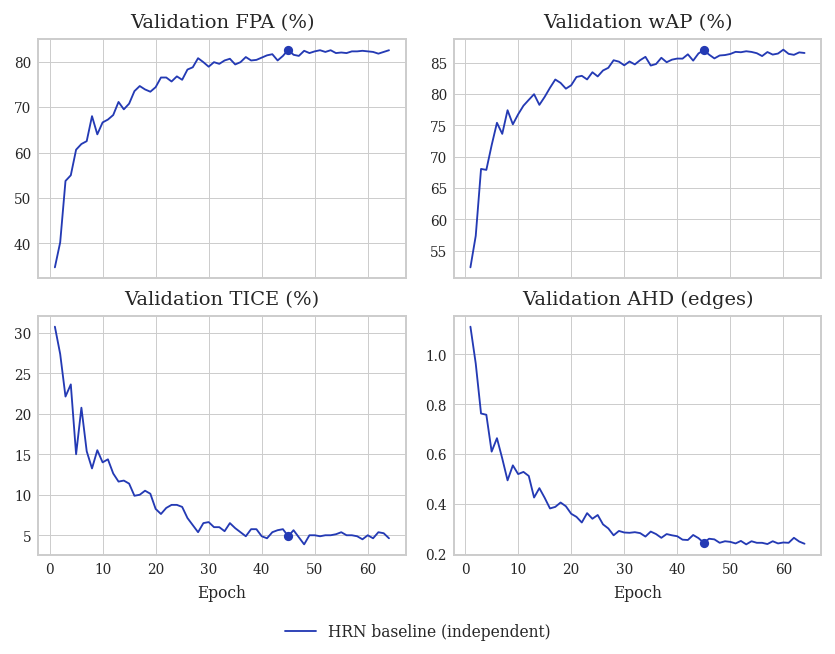

**Aircraft: validation metrics (independent decoding)**

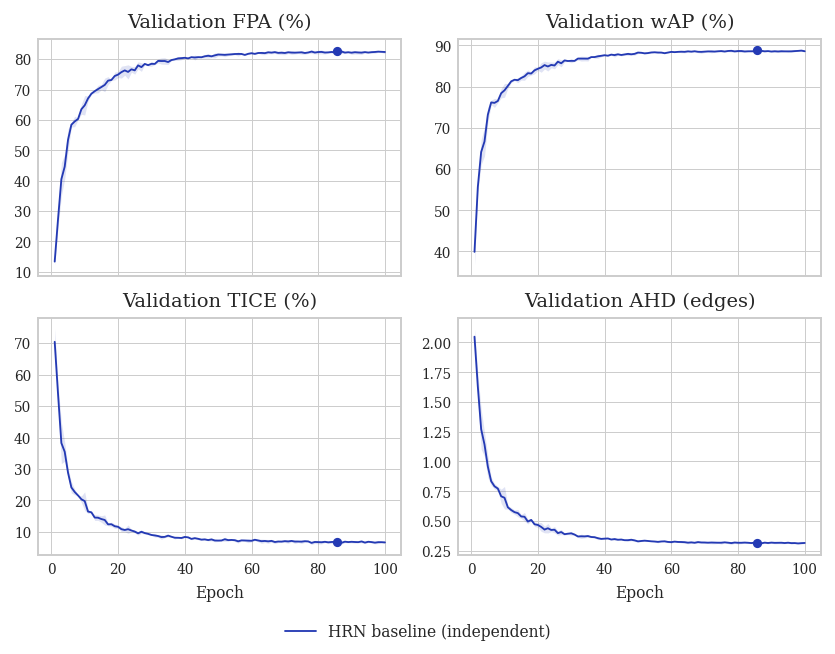

In [3]:
analysis.plot_validation_curves()

## Per-level validation accuracy

The same runs resolved by hierarchy level, coarsest panel first. Read against the
FPA panel above, this separates a run that gained fine accuracy from one that gained
full-path accuracy by repairing its coarse predictions.

In the coarsest panel the two decoder lines coincide exactly, because top-down decoding
starts at that level and cannot differ from independent decoding there. They are drawn
anyway: the coincidence is the check that the top-down decoder is anchored where it
should be, and the deeper panels are where the two separate.

**CUB-200: per-level validation accuracy**

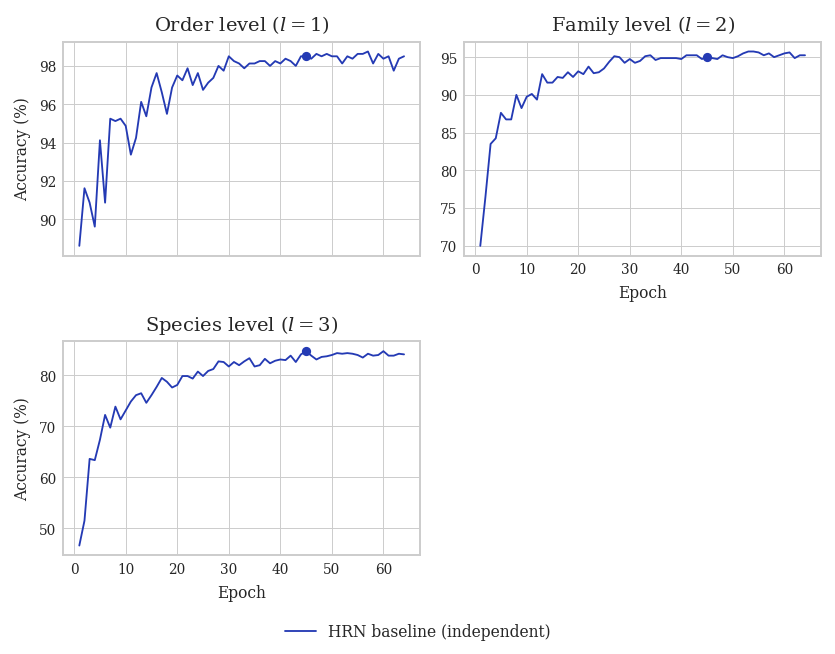

**Aircraft: per-level validation accuracy**

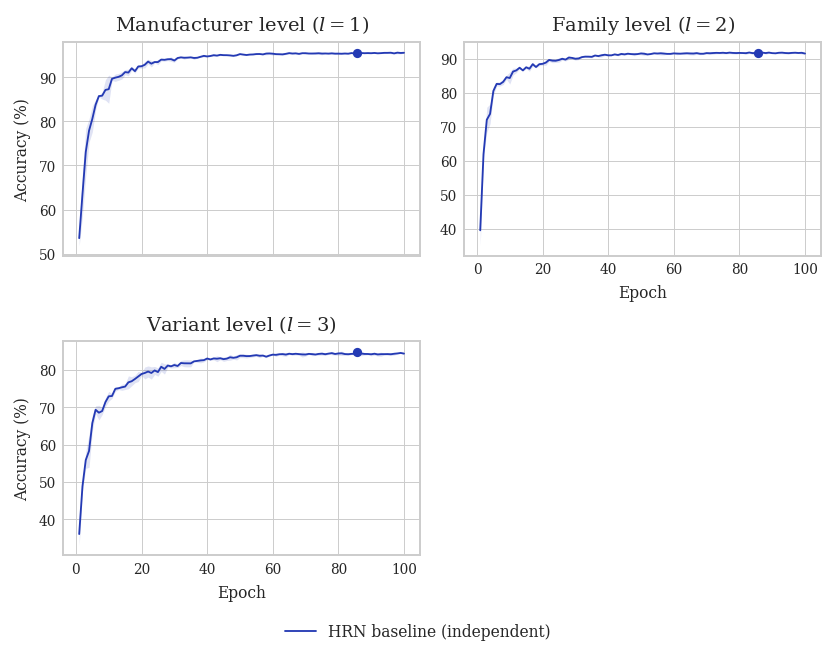

In [4]:
analysis.plot_per_level_validation_accuracy()

## Final selected-checkpoint level accuracy

The three datasets are shown in one row. Points are independent-decoding test
accuracy means at the independently selected checkpoint, error bars are one
sample standard deviation across seeds, and lines connect hierarchy levels
within the same run. The vertical axis is shared and adapts to the visible values and error bars.

**Final selected-checkpoint level accuracy (independent decoding)**

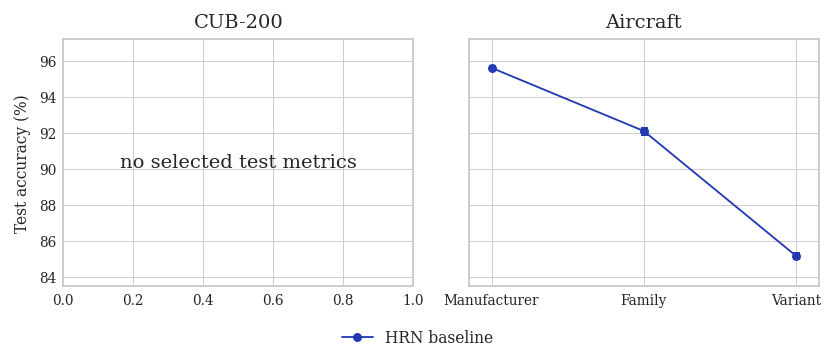

In [5]:
analysis.plot_final_level_test_accuracy(decoder_view='independent')

## Training losses

Two figures: the terms of the aggregate objective, then the per-level terms. The
terms plotted are the ones the family profile names, minus any the selected runs
never logged; two keys that are aliases of a single quantity collapse to one panel.

A family whose objective does not decompose into per-level terms has no second
figure here, and says so - for HRN that is the difference between the plain
baseline and the `level_marginal` arms.

**CUB-200: terms of the training objective**

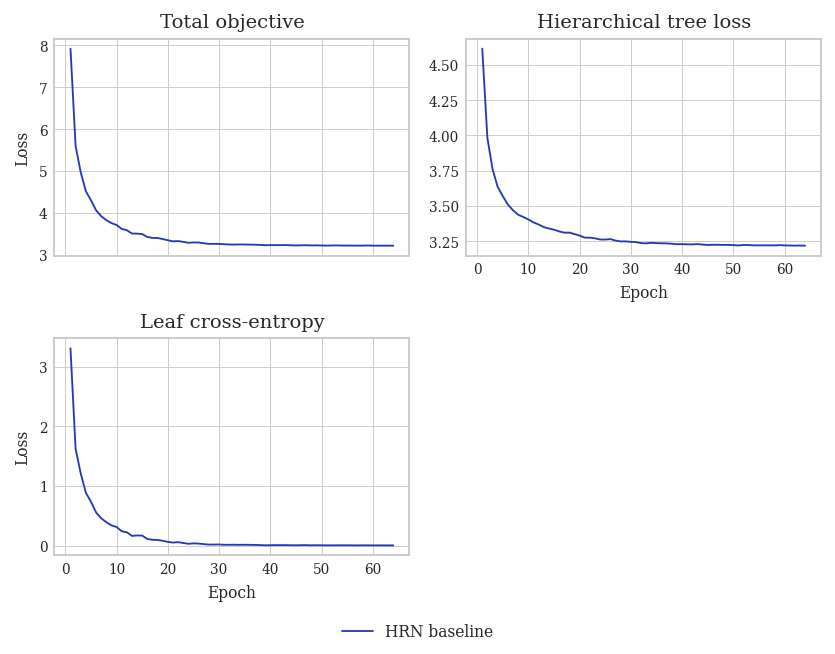

**CUB-200: per-level training objectives**

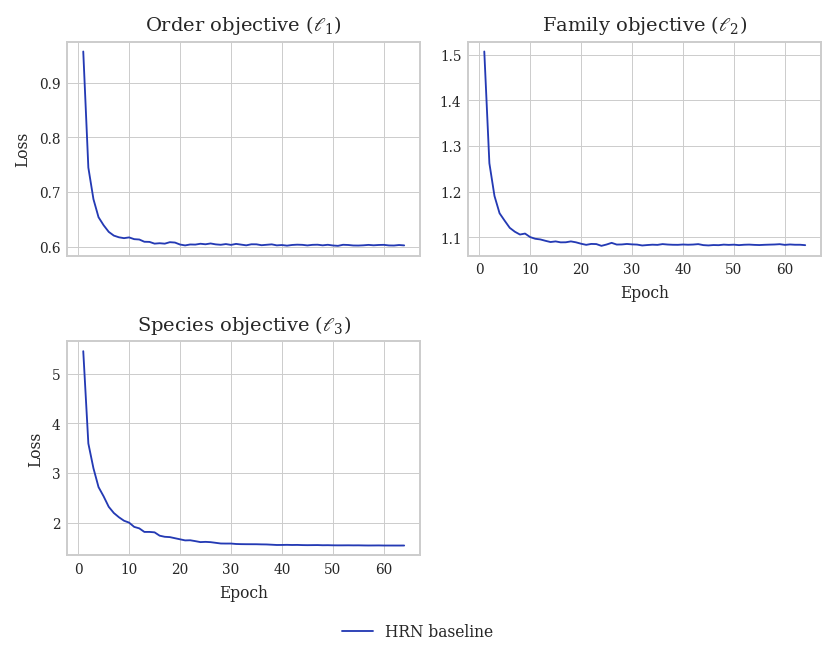

**Aircraft: terms of the training objective**

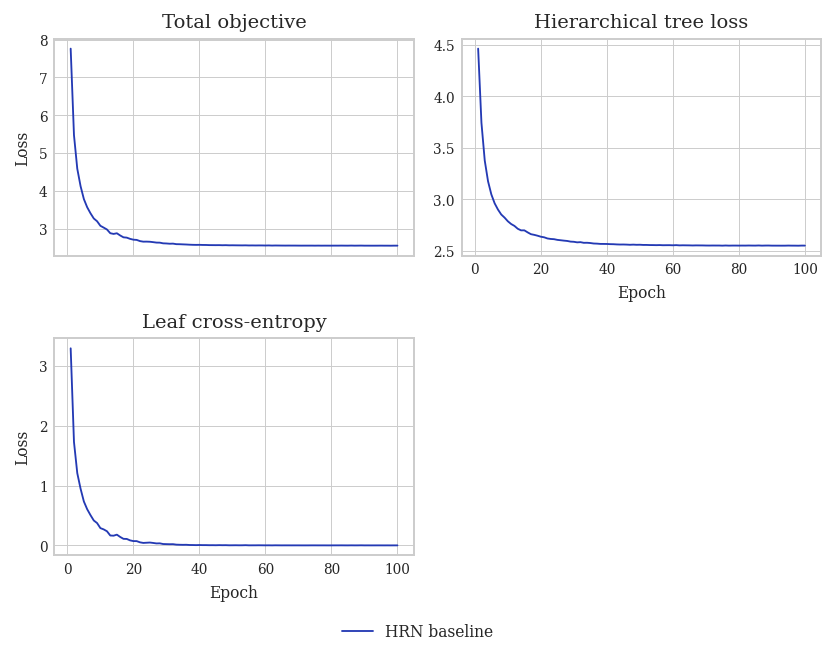

**Aircraft: per-level training objectives**

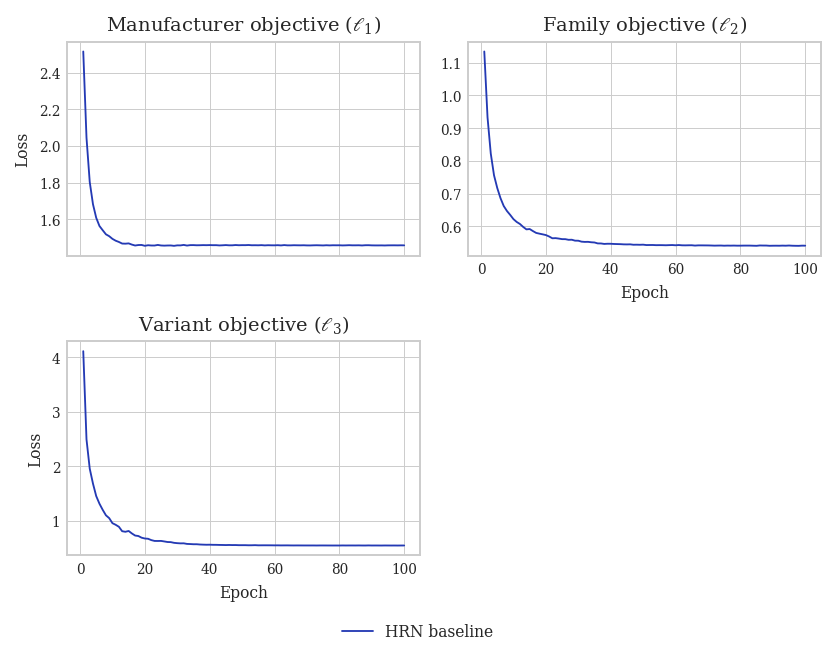

In [6]:
analysis.plot_training_losses()

## Effective level-loss weights

The weight each level objective actually carried, epoch by epoch. Only some families
weight their level losses and those that do can weight them dynamically, so a
comparison between two arms with different `weight_mode` mixes the mechanism under
test with a change in level weighting; this section is what makes that second
variable explicit rather than implicit.

One caveat when reading a lexicographic arm: the lexicographic step is rebuilt from
the per-level gradients, so check whether the logged weight still scales the applied
update for this family before reading a difference here as causal. A family that
logs no weights prints a line and the section stays empty.

In [7]:
analysis.plot_level_loss_weights()

[CUB-200] no level-loss weights logged in the selected runs.
[Aircraft] no level-loss weights logged in the selected runs.


## Level objectives within each run

The previous section compares one objective across runs; this one keeps the levels
of a single run together in one panel, which is where a run that trades shallow loss
for deep loss becomes visible.

**CUB-200: level objectives within each run**

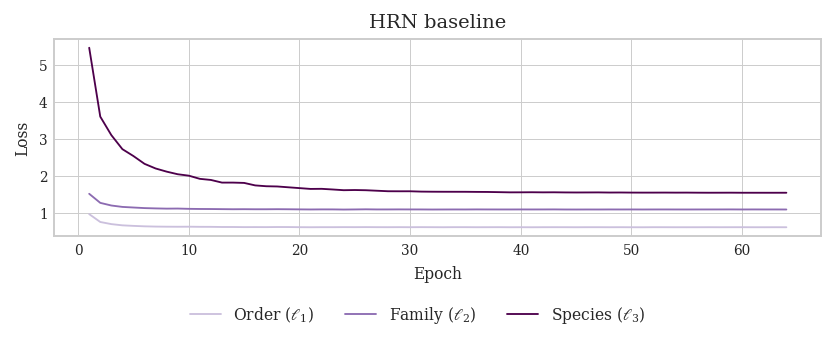

**Aircraft: level objectives within each run**

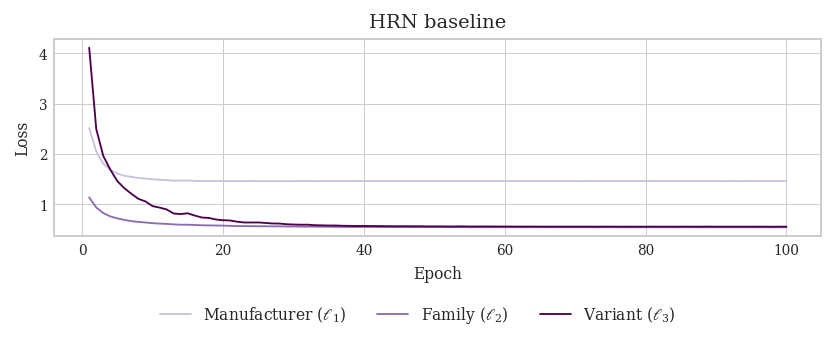

In [8]:
analysis.plot_per_run_per_level_training_losses()

## Gradient and parameter diagnostics

Up to five figures, all indexed by exact gradient-support block rather than by a
family's own parameter names, because which blocks exist is a property of the
architecture: H-CAST branches fine-to-coarse and has $P_{123}$/$P_{12}$/$P_1$,
HT-CapsNet runs the reverse cascade and has $P_{123}$/$P_{23}$/$P_3$, HRN and
Hier-COS share one trunk and have $P_{123}$ alone. A shorter figure here is the
architecture, not a missing measurement.

The last two figures - projected cosines against their own pre-projection values,
and the projection steps skipped for numerical safety - exist only for runs trained
with `train.lexicographic.enabled`, and the section says so when none were
selected.

**CUB-200: level gradient norms on the shared blocks**

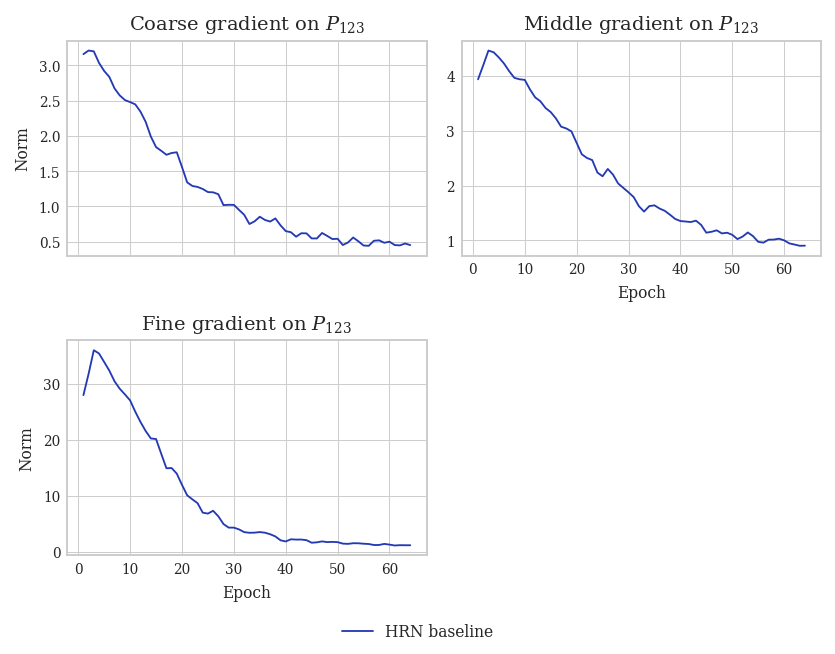

**CUB-200: pairwise gradient alignment**

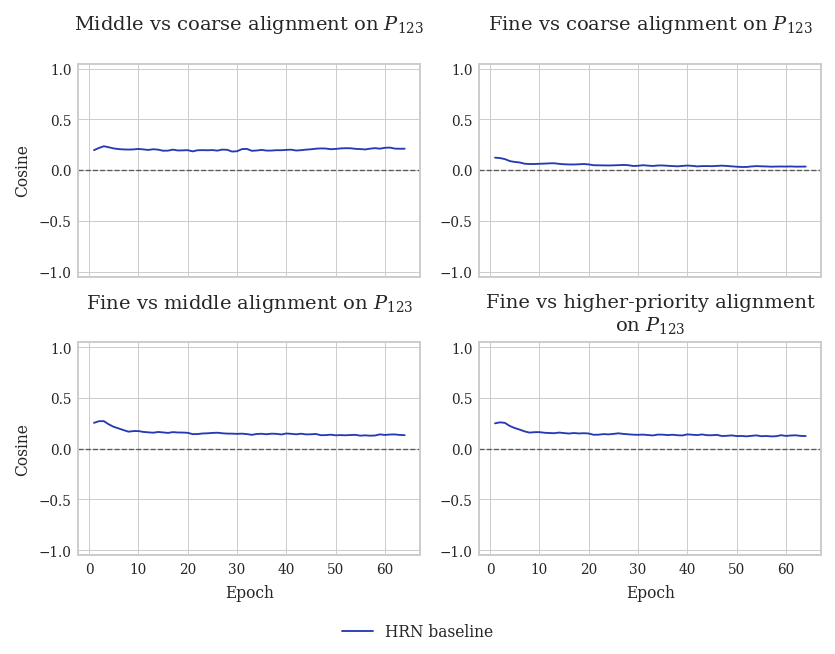

**CUB-200: parameter scale and per-epoch movement**

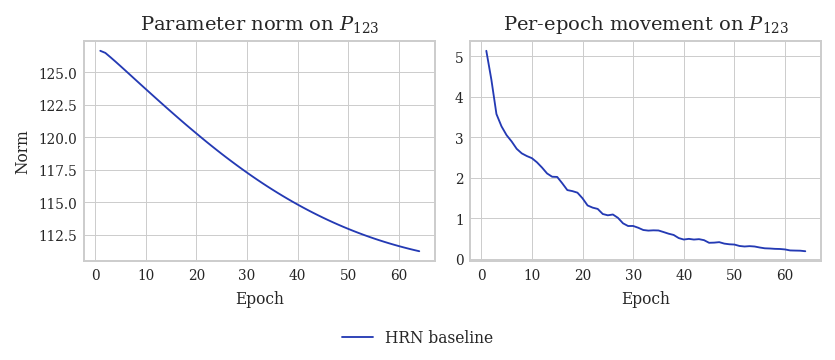

[CUB-200] no post-projection diagnostics: none of the selected runs were trained with train.lexicographic.enabled.


**Aircraft: level gradient norms on the shared blocks**

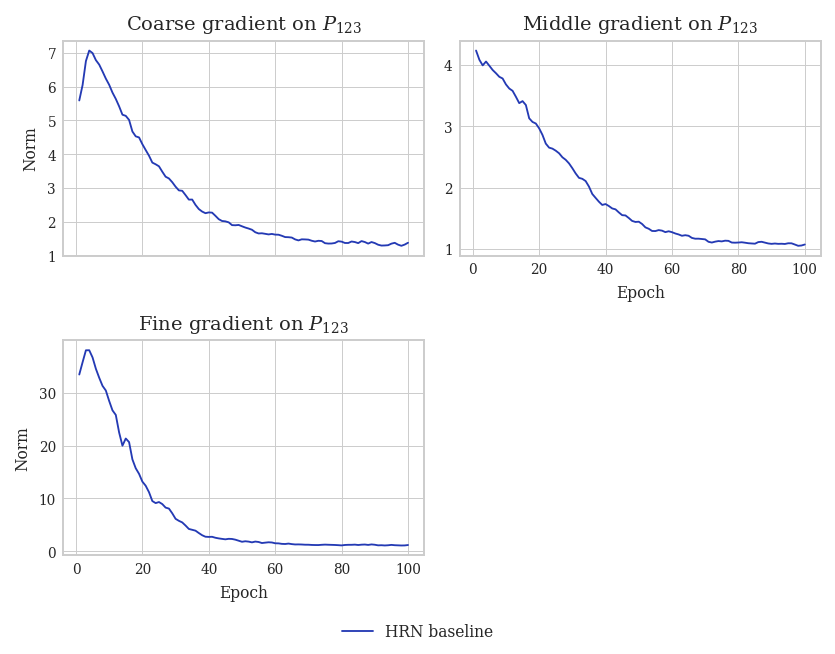

**Aircraft: pairwise gradient alignment**

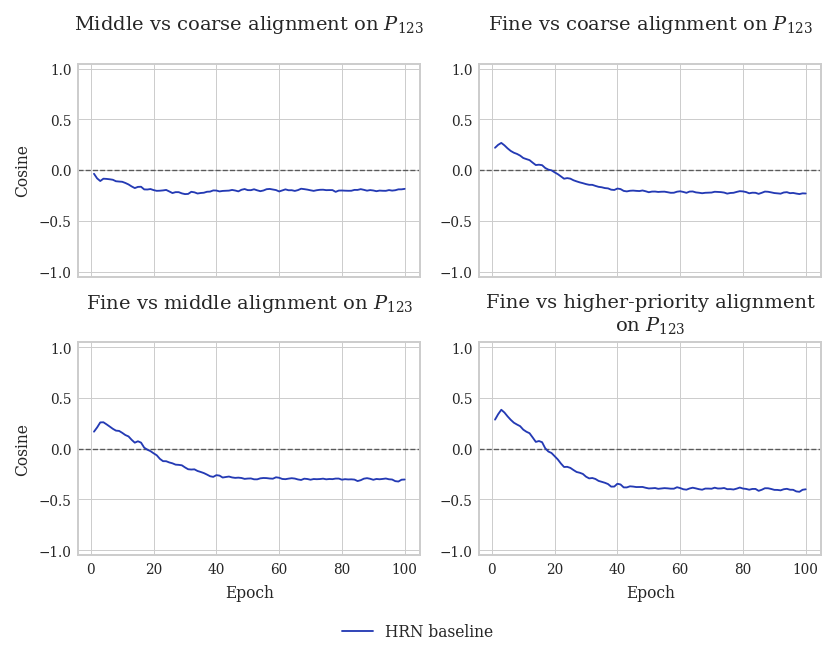

**Aircraft: parameter scale and per-epoch movement**

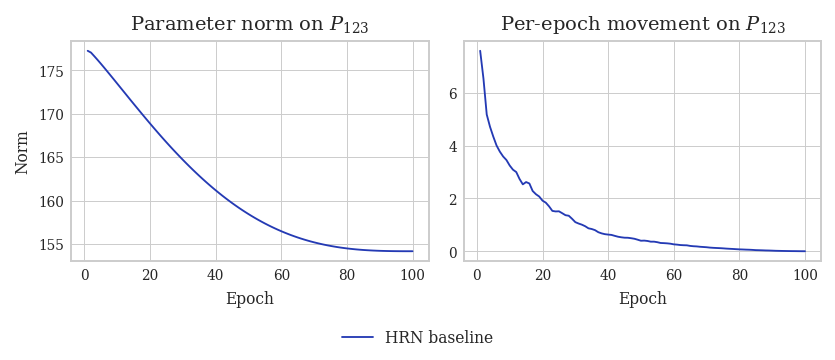

[Aircraft] no post-projection diagnostics: none of the selected runs were trained with train.lexicographic.enabled.


In [9]:
analysis.plot_gradient_diagnostics()

## Output-space constraint diagnostics

One shared panel list for every family, `MECHANISM_DIAGNOSTIC_SPECS`, filtered three
ways so that what survives is what carries information. A panel is dropped when no
selected run logs the key at all; when its value is the same constant in every run,
in which case the constant is named, so "held at 1" confirms a binary switch was on
for the whole run without spending a panel on a flat line; and when it traces the
identical curve to a panel already on the page, in which case that panel is named.

The last of those is what removes the "after" panels on a family whose mechanism never
ran, since nothing rewrote the scores and "after" is a copy of "before", and the
residual reduction on one that did, since the post-projection residual sits at
numerical zero and the reduction is therefore the residual before it. What is left is
the set of quantities some mechanism actually moved, which makes the panel count
itself a readout of whether it fired.

The trailing panels are structural rather than mechanistic and are present for every
family: how much fine probability mass sits under the true parent, where the true
class ranks among its siblings, how often the parent is correct, and how accurate
the fine level is when it is. Those describe the hierarchy a run learned whether or
not any output-space correction was applied to it.

[CUB-200] constant in every selected run, so not plotted: Total fine probability shift (held at 0); True-class fine probability shift (held at 0); Fine prediction flip rate (held at 0).
[CUB-200] duplicates a panel already on this page, so not plotted: Fine mass under the true parent, after (identical to Fine mass under the true parent, before); True-class rank among siblings, after (identical to True-class rank among siblings, before).


**CUB-200: output-space constraint diagnostics**

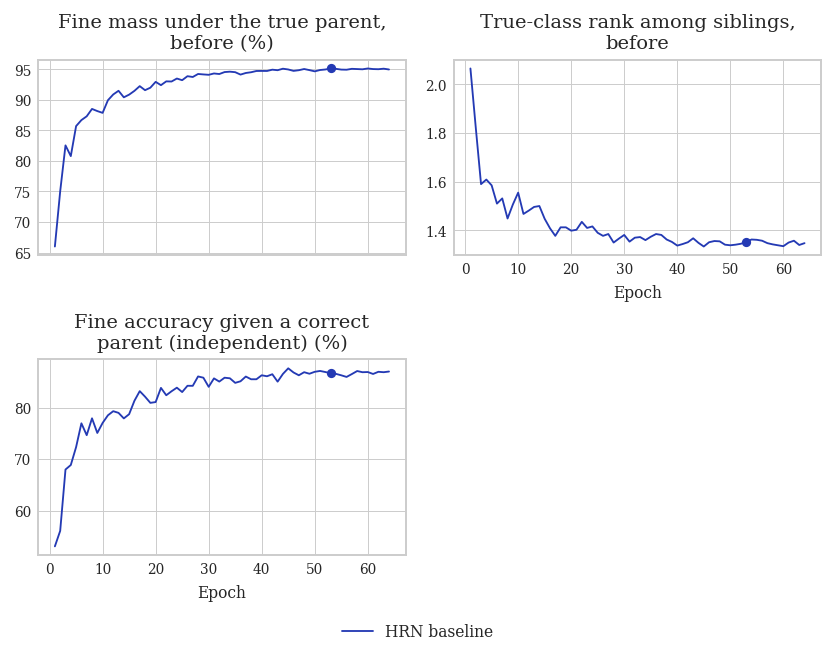

[Aircraft] constant in every selected run, so not plotted: Total fine probability shift (held at 0); True-class fine probability shift (held at 0); Fine prediction flip rate (held at 0).
[Aircraft] duplicates a panel already on this page, so not plotted: Fine mass under the true parent, after (identical to Fine mass under the true parent, before); True-class rank among siblings, after (identical to True-class rank among siblings, before).


**Aircraft: output-space constraint diagnostics**

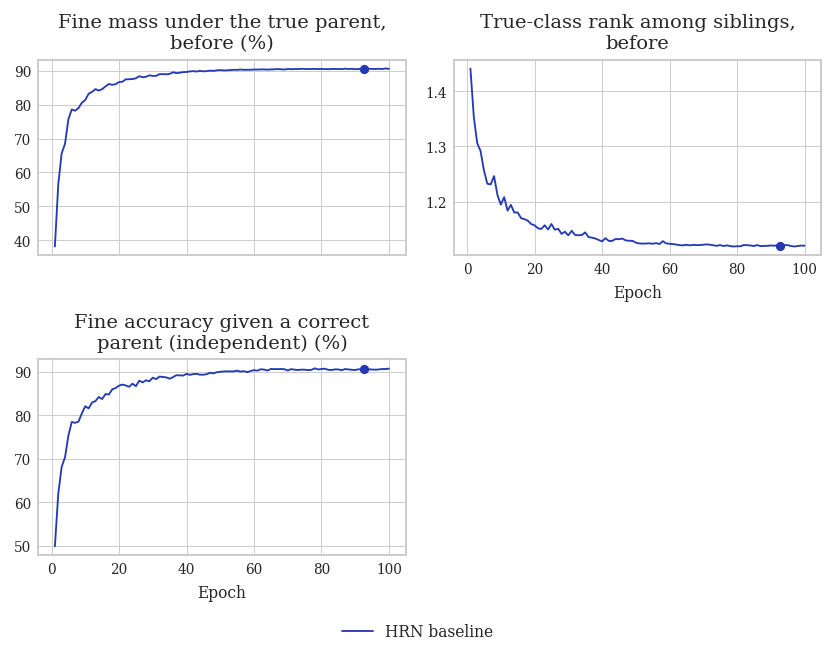

In [10]:
analysis.plot_projection_diagnostics()

## Final selected-checkpoint test tables

Test metrics read from `test_metrics.yaml`, each row at the checkpoint selected for
its own decoder: top-down rows use the top-down-selected checkpoint and independent
rows the independent-selected one. Cells are mean ± standard deviation over the
seeds named in the run matrix; deltas against the baseline are in percentage points
for percentages and in edges for AHD. The best value in a row is bold and the second
best underlined, and a dataset with a single run reports absolute values only.

Two rows are degenerate by construction rather than by accident of these runs, and are
tabulated anyway because the identity is worth showing: TICE under top-down decoding is
zero, because that decoder enforces consistency, and full-path accuracy under top-down
decoding equals the fine-level accuracy, because a correct leaf there implies a correct
path. A value that departs from either is a bug, not a result.

In [11]:
analysis.show_final_test_tables(allow_single_run=True)

### Dataset: `cub-200-2011`
Baseline run: **HRN baseline**

| Metric | HRN baseline (n=1) |
|---|---:|
| Best epoch (Ind) | n/a |
| FPA (independent) ↑ | n/a |
| wAP (independent) ↑ | n/a |
| TICE (independent) ↓ | n/a |
| AHD (independent) ↓ | n/a |
| Order accuracy (independent) ↑ | n/a |
| Family accuracy (independent) ↑ | n/a |
| Species accuracy (independent) ↑ | n/a |

### Dataset: `fgvc-aircraft`
Baseline run: **HRN baseline**

| Metric | HRN baseline (n=3) |
|---|---:|
| Best epoch (Ind) | 85.7 ± 13.1 |
| FPA (independent) ↑ | 83.25% ± 0.18% |
| wAP (independent) ↑ | 89.15% ± 0.14% |
| TICE (independent) ↓ | 6.59% ± 0.30% |
| AHD (independent) ↓ | 0.303 ± 0.001 |
| Manufacturer accuracy (independent) ↑ | 95.60% ± 0.11% |
| Family accuracy (independent) ↑ | 92.09% ± 0.19% |
| Variant accuracy (independent) ↑ | 85.15% ± 0.17% |

## Exported figures

The authored size of every figure written above. They are authored at final printed
width and must be included with `width=\linewidth` and no further scaling, since
any resizing in LaTeX shrinks the fonts along with the artwork. A figure taller than
the usable text height is flagged here rather than silently overflowing its page.

In [12]:
thesis_style.report_exported(hu.EXPORTED_FIGURES)

19 figures exported (authored size, in inches):
  hrn_cub200_validation_curves                         5.91 x 4.58
  hrn_aircraft_validation_curves                       5.91 x 4.58
  hrn_cub200_per_level_accuracy                        5.91 x 4.58
  hrn_aircraft_per_level_accuracy                      5.91 x 4.58
  hrn_final_level_accuracy                             5.91 x 2.48
  hrn_cub200_training_losses_aggregate                 5.91 x 4.58
  hrn_cub200_training_losses_per_level                 5.91 x 4.58
  hrn_aircraft_training_losses_aggregate               5.91 x 4.58
  hrn_aircraft_training_losses_per_level               5.91 x 4.58
  hrn_cub200_level_losses_per_run                      5.91 x 2.33
  hrn_aircraft_level_losses_per_run                    5.91 x 2.33
  hrn_cub200_gradient_norms                            5.91 x 4.58
  hrn_cub200_gradient_alignment                        5.91 x 4.58
  hrn_cub200_parameter_movement                        5.91 x 2.48
  hrn_aircraft